# 🔬 Notebook 03: Your First Multi-Agent Simulation

Welcome to the world of Agent-Based Modeling (ABM)! In our previous notebooks, we simulated an epidemic from a "top-down" perspective using equations. Now, we're going to build it from the "bottom-up".

**What's an Agent-Based Model?**
Instead of tracking the total number of Susceptible, Infected, and Recovered people, we will create individual "agents" that represent each person. Each agent will have its own state and rules for behavior. The large-scale epidemic curve will *emerge* from the simple, individual interactions of thousands of agents.

**Today's Goals:**
1.  **Install `Mesa`**: The primary library for ABM in Python.
2.  **Create a `PersonAgent`**: Define what a single person can do (move, get sick, recover).
3.  **Build an `EpidemicModel`**: Create the "world" or "city" where our agents live.
4.  **Run the Simulation**: Unleash the agents and watch the epidemic unfold.
5.  **Visualize the Spread**: See not just *how many* people get sick, but *where* they get sick on a city grid.

In [13]:
# First, let's install the Mesa library right here in the notebook.
# The '!' tells Jupyter to run this as a command line command.
print("Installing Mesa library...")
%pip install --quiet
print("Mesa installation complete!")

# Now, import all the necessary libraries
import mesa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# Plotting settings for better visuals
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("\nLibraries imported successfully. We are ready to build our agents!")

Installing Mesa library...
Note: you may need to restart the kernel to use updated packages.
Mesa installation complete!

Libraries imported successfully. We are ready to build our agents!



[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: You must give at least one requirement to install (see "pip help install")


## Step 1: Defining the Agent

An agent is the fundamental building block of our model. It's an object that has its own properties (like its health state) and its own behavior (like moving or infecting others). We will create a `PersonAgent` that can be Susceptible, Infected, or Recovered.

In [35]:
# An enumeration is a clean way to define a set of named constants.
# It makes the code more readable than using numbers like 0, 1, 2.
class State:
    SUSCEPTIBLE = 0
    INFECTED = 1
    RECOVERED = 2

class PersonAgent(mesa.Agent):
    """Represents a single person in our city."""
    
    def __init__(self, model):
        # Every agent in Mesa needs a unique_id and a reference to the model.
        super().__init__(model)
        # All agents start as healthy and susceptible to the disease.
        self.state = State.SUSCEPTIBLE
        # We'll track how long an agent has been infected.
        self.infection_time = 0

    def step(self):
        """This method is called for every agent at each step of the simulation."""
        
        # --- Infection and Recovery Logic ---
        if self.state == State.INFECTED:
            # If infected, check for recovery first
            if self.model.random.random() < self.model.recovery_rate:
                self.state = State.RECOVERED
            else:
                # If not recovered, try to infect neighbors
                self.infect_neighbors()
        
        # --- Movement Logic ---
        # Agents move to a random neighboring cell.
        self.move()

    def move(self):
        """Find a random empty cell nearby and move there."""
        # get_neighborhood returns a list of cells around the agent.
        # moore=True means we include diagonal neighbors.
        possible_steps = self.model.grid.get_neighborhood(
            self.pos,
            moore=True,
            include_center=False
        )
        # Move to a random one of these cells.
        new_position = self.random.choice(possible_steps)
        self.model.grid.move_agent(self, new_position)

    def infect_neighbors(self):
        """Infect susceptible neighbors in the same cell."""
        # get_cell_list_contents gets all agents in a specific cell (our current position).
        cellmates = self.model.grid.get_cell_list_contents([self.pos])
        
        # We only care if there's more than one agent in our cell.
        if len(cellmates) > 1:
            for other_agent in cellmates:
                # We can't infect ourselves or non-susceptible people.
                if other_agent.state == State.SUSCEPTIBLE:
                    # Infect with a probability defined in the model.
                    if self.model.random.random() < self.model.transmission_rate:
                        other_agent.state = State.INFECTED

print("✅ PersonAgent class defined successfully.")

✅ PersonAgent class defined successfully.


## Step 2: Defining the Model

The `Model` is the container for our simulation. It holds all the agents, manages the environment (the city grid), and controls the order of operations using a scheduler. It also collects data for us to analyze later.

In [36]:
class EpidemicModel(mesa.Model):
    """The main model that runs the simulation."""
    
    def __init__(self, N=100, width=10, height=10, transmission_rate=0.3, recovery_rate=0.1, p_initial_infected=0.1):
        # --- Mandatory Mesa setup ---
        super().__init__() # <-- THE FIX! This initializes the model's core components.
        
        # Store all the parameters
        self.num_agents = N
        self.transmission_rate = transmission_rate
        self.recovery_rate = recovery_rate
        
        # The grid is the spatial environment where agents live.
        # MultiGrid allows multiple agents to be in the same cell.
        self.grid = mesa.space.MultiGrid(width, height, True)
        
        # The scheduler determines the order in which agents are activated each step.
        # RandomActivation activates them in a random order.
        # self.schedule = mesa.time.RandomActivation(self)
        
        self.running = True # A flag to stop the simulation when the disease is gone.

        # --- Create Agents ---
        for i in range(self.num_agents):
            a = PersonAgent(self)
            #self.schedule.add(a)
            
            # Place agent on a random grid cell
            x = self.random.randrange(self.grid.width)
            y = self.random.randrange(self.grid.height)
            self.grid.place_agent(a, (x, y))

            # Make a percentage of the population initially infected
            if self.random.random() < p_initial_infected:
                a.state = State.INFECTED

        # --- Data Collection ---
        # The DataCollector is a powerful Mesa tool to track model-level and agent-level variables.
        self.datacollector = mesa.DataCollector(
            model_reporters={
                "Susceptible": lambda m: self.count_states(m, State.SUSCEPTIBLE),
                "Infected": lambda m: self.count_states(m, State.INFECTED),
                "Recovered": lambda m: self.count_states(m, State.RECOVERED),
            }
        )
    
    @staticmethod
    def count_states(model, state):
        """A helper function to count agents in a given state."""
        return sum(1 for a in model.agents if a.state == state)

    def step(self):
        """Execute one step of the simulation."""
        self.datacollector.collect(self) # Collect data BEFORE the step
        self.agents.shuffle_do("step") # Activate all agents
        
        # Stop the simulation if there are no more infected agents
        if self.count_states(self, State.INFECTED) == 0:
            self.running = False

print("✅ EpidemicModel class defined successfully (with corrections for new Mesa version).")

✅ EpidemicModel class defined successfully (with corrections for new Mesa version).


## Step 3: Running the Simulation & Analyzing Results

Now for the exciting part! We'll set our parameters, create an instance of our `EpidemicModel`, run it for a set number of steps, and then use the `DataCollector` to plot the results. The curve should look familiar, but this time it emerged from individual agent interactions!

Initializing the model...
Running simulation for 150 steps...
Simulation stopped early at step 144 as there are no more infections.
Simulation complete.
Analyzing results...


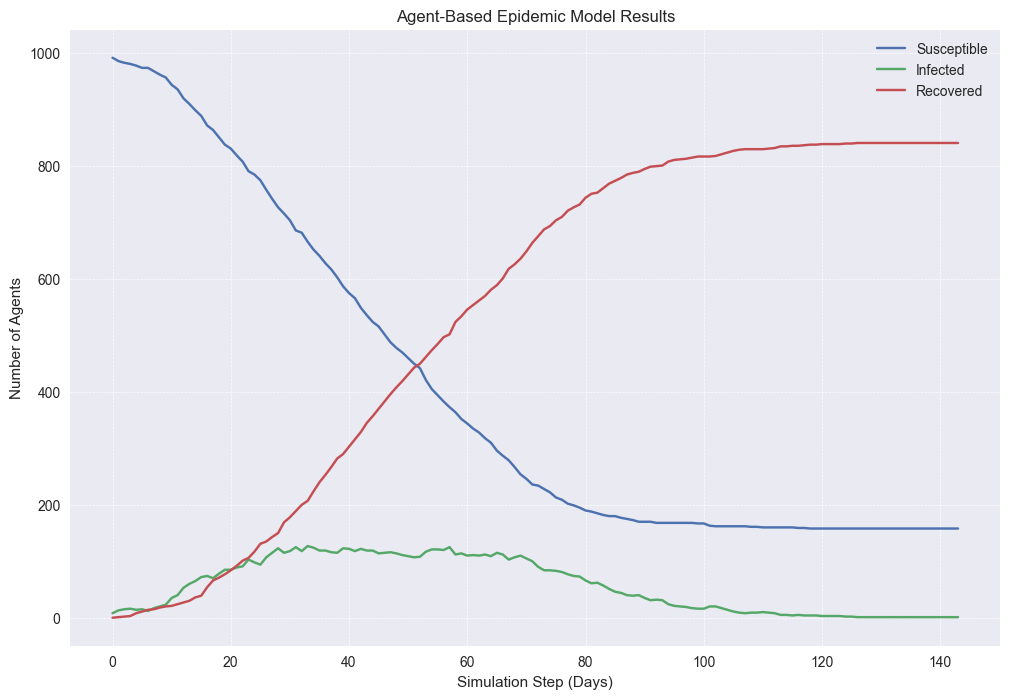


--- Simulation Summary ---
Peak number of infected agents: 127
Total agents recovered by the end: 841


In [43]:
# --- Set Simulation Parameters ---
POPULATION = 1000
GRID_WIDTH = 30
GRID_HEIGHT = 30
TRANSMISSION_RATE = 0.3  # Probability of infecting a cellmate
RECOVERY_RATE = 0.1      # Probability of recovering each step
INITIAL_INFECTED_P = 0.01 # Percentage of population initially infected
SIMULATION_STEPS = 150

# --- Create and Run the Model ---
print("Initializing the model...")
model = EpidemicModel(
    N=POPULATION,
    width=GRID_WIDTH,
    height=GRID_HEIGHT,
    transmission_rate=TRANSMISSION_RATE,
    recovery_rate=RECOVERY_RATE,
    p_initial_infected=INITIAL_INFECTED_P
)

print(f"Running simulation for {SIMULATION_STEPS} steps...")
for i in range(SIMULATION_STEPS):
    if model.running:
        model.step()
    else:
        print(f"Simulation stopped early at step {i} as there are no more infections.")
        break
print("Simulation complete.")

# --- Extract and Plot Data ---
print("Analyzing results...")
results_df = model.datacollector.get_model_vars_dataframe()

# Plot the results
results_df.plot(figsize=(12, 8), title="Agent-Based Epidemic Model Results")
plt.xlabel("Simulation Step (Days)")
plt.ylabel("Number of Agents")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

# Print summary statistics
peak_infections = results_df["Infected"].max()
total_recovered = results_df["Recovered"].iloc[-1]
print(f"\n--- Simulation Summary ---")
print(f"Peak number of infected agents: {peak_infections}")
print(f"Total agents recovered by the end: {total_recovered}")

## Step 4: Visualizing the Spatial Spread

This is something we could *never* do with our old equation-based model. Because our agents live on a grid, we can create a map of our city and watch the infection spread visually. This shows us hotspots and the geographic dynamics of the outbreak.

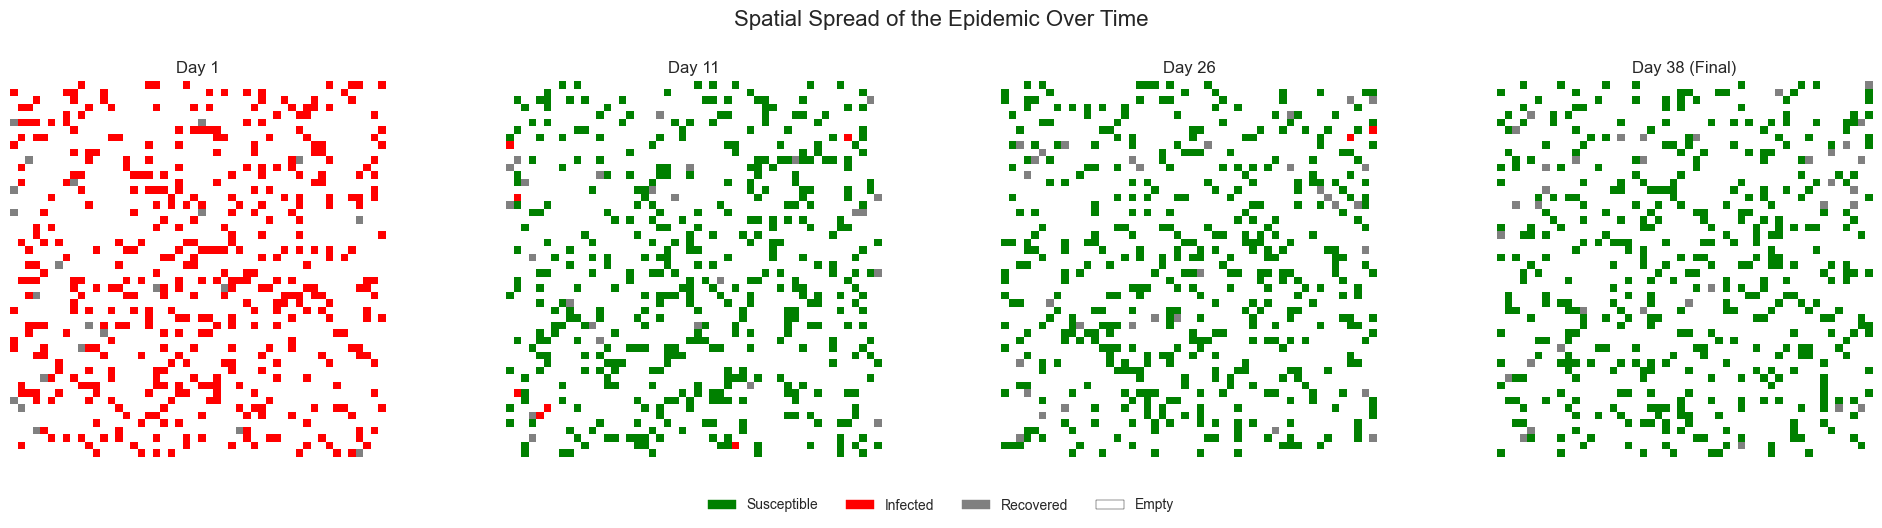

In [44]:
# Helper function to get grid data for plotting
def get_grid_data(model):
    """Converts the agent grid to a NumPy array for visualization."""
    grid_data = np.zeros((model.grid.width, model.grid.height))
    for cell in model.grid.coord_iter():
        cell_content, (x, y) = cell
        if cell_content:
            # If multiple agents, we just show the state of the first one for simplicity
            # A more advanced viz could show a mix of colors
            agent = cell_content[0]
            grid_data[x][y] = agent.state
        else:
            grid_data[x][y] = -1 # -1 for empty cells
    return grid_data

# --- Plotting Snapshots of the Simulation ---
# Re-run a smaller simulation to capture snapshots
model = EpidemicModel(N=500, width=50, height=50, transmission_rate=0.4, recovery_rate=0.1, p_initial_infected=0.05)

snapshots = {}
for i in range(100):
    # Store a snapshot at specific steps
    if i in [0, 10, 25, 50, 99]:
        snapshots[f'Day {i+1}'] = get_grid_data(model)
    model.step()
    if not model.running:
        snapshots[f'Day {i+1} (Final)'] = get_grid_data(model)
        break

# --- Create the Visualization ---
fig, axes = plt.subplots(1, len(snapshots), figsize=(20, 5))
fig.suptitle('Spatial Spread of the Epidemic Over Time', fontsize=16)

# Define a color map: -1:White (Empty), 0:Green (S), 1:Red (I), 2:Gray (R)
from matplotlib.colors import ListedColormap
cmap = ListedColormap(['white', 'green', 'red', 'gray'])

for i, (day, grid) in enumerate(snapshots.items()):
    ax = axes[i]
    ax.imshow(grid.T, cmap=cmap, interpolation='nearest') # Transpose for correct (x,y) orientation
    ax.set_title(day)
    ax.set_xticks([])
    ax.set_yticks([])

# Create a legend
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color='green', label='Susceptible'),
    mpatches.Patch(color='red', label='Infected'),
    mpatches.Patch(color='gray', label='Recovered'),
    mpatches.Patch(color='white', label='Empty', ec='black')
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout(rect=[0, 0.05, 1, 0.95]) # Adjust layout to make space for suptitle and legend
plt.show()

## 🎉 Congratulations & Next Steps

You have successfully built and visualized your first Multi-Agent Simulation!

**What's different now?**
- **Emergent Behavior**: The S-I-R curve wasn't programmed in; it *emerged* from thousands of simple, local interactions.
- **Spatial Dynamics**: We can see *where* the disease is spreading, identifying potential hotspots.
- **Individual Detail**: Each agent is unique. We could give them individual properties like age or pre-existing conditions in the future.

This is a massive leap forward. We now have a flexible foundation to build upon.